# Predicting Singapore HDB Resale Prices

In this notebook you will build three regression models, compare them fairly, and choose one to deploy as a Streamlit web app.

**By the end you will be able to:**
1. Explore a real dataset and turn raw columns into model-ready features.
2. Use a scikit-learn `Pipeline` to one-hot encode text columns.
3. Train **Linear Regression**, **Random Forest** and **Gradient Boosting** regressors.
4. Evaluate regression models with **MAE**, **RMSE** and **R²**.
5. Compare models with **cross-validation** and choose one for deployment, weighing accuracy against size, speed and interpretability.

**Roadmap**

| Part | What we do |
|---|---|
| 1 | Load and inspect the data |
| 2 | Feature engineering |
| 3 | Exploratory data analysis (EDA) |
| 4 | Train/test split and preprocessing |
| 5 | Model 1: Linear Regression |
| 6 | Model 2: Random Forest |
| 7 | Model 3: Gradient Boosting |
| 8 | Fair comparison with cross-validation |
| 9 | Choose, test and explain the final model |
| 10 | From notebook to app |

## Part 0: Setup

In [2]:
import io
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Shared helpers also used by model.py and app.py
from hdb_features import add_features, load_data, storey_midpoint

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)
RANDOM_STATE = 42

## Part 1: Load and inspect the data

The dataset contains HDB resale transactions from **January 2017 to May 2019**, originally published on [data.gov.sg](https://data.gov.sg). A copy lives in `data/` so this notebook works offline.

Each row is one resale transaction.

In [3]:
df = load_data()
print(df.shape)
df.head()

(50432, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,"232,000.00"
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,"250,000.00"
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"262,000.00"
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.00,New Generation,1980,62 years 01 month,"265,000.00"
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"265,000.00"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50432 entries, 0 to 50431
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                50432 non-null  str    
 1   town                 50432 non-null  str    
 2   flat_type            50432 non-null  str    
 3   block                50432 non-null  str    
 4   street_name          50432 non-null  str    
 5   storey_range         50432 non-null  str    
 6   floor_area_sqm       50432 non-null  float64
 7   flat_model           50432 non-null  str    
 8   lease_commence_date  50432 non-null  int64  
 9   remaining_lease      50432 non-null  str    
 10  resale_price         50432 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 7.8 MB


In [5]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,"50,432.00","50,432.00","50,432.00"
mean,97.94,"1,993.26","440,591.89"
std,24.23,12.16,"154,048.45"
min,31.00,"1,966.00","160,000.00"
25%,82.00,"1,984.00","330,000.00"
50%,96.00,"1,993.00","408,000.00"
75%,113.00,"2,002.00","512,888.00"
max,249.00,"2,016.00","1,200,000.00"


**What does each column mean, and should we use it?**

| Column | Meaning | Use as a feature? |
|---|---|---|
| `month` | Month of sale | No. Only ~2.5 years of data, and prices were fairly flat over this period |
| `town` | HDB town, e.g. `BISHAN` | **Yes**: location is a key driver of price |
| `flat_type` | `3 ROOM`, `4 ROOM`, `EXECUTIVE`, ... | **Yes** |
| `block`, `street_name` | Address | No. Too many unique values for this lesson |
| `storey_range` | Floor band, e.g. `10 TO 12` | **Yes**, after converting to a number |
| `floor_area_sqm` | Size of the flat | **Yes** |
| `flat_model` | Design, e.g. `Improved`, `DBSS` | Optional (see exercises) |
| `lease_commence_date` | Year the 99-year lease started | **Yes**: older flats have less lease left |
| `remaining_lease` | Text such as `61 years 04 months` | No. Almost the same information as `lease_commence_date` |
| `resale_price` | Price in S$ | **Target**: this is what we predict |

In [6]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 29


There are no missing values. The few duplicate rows can be genuine: two identical flats in the same block can both sell in the same month, so we keep them.

## Part 2: Feature engineering

Models need numbers. `storey_range` is text like `"10 TO 12"`, so we convert each band to its **midpoint**: `"10 TO 12"` becomes `11.0`.

In [7]:
example = pd.Series(["01 TO 03", "10 TO 12", "49 TO 51"])
bounds = example.str.split(" TO ", expand=True).astype(int)
print(bounds)
print("Midpoints:", ((bounds[0] + bounds[1]) / 2).tolist())

    0   1
0   1   3
1  10  12
2  49  51
Midpoints: [2.0, 11.0, 50.0]


We put this logic in a function, `storey_midpoint`, inside **`hdb_features.py`**. The training script *and* the web app both import it, so features are always built the same way. If training and serving code compute features differently, the deployed model silently gives wrong answers.

In [8]:
df = add_features(df)
df[["storey_range", "storey"]].drop_duplicates().sort_values("storey").head(10)

,storey_range,storey
1,01 TO 03,2.00
3,04 TO 06,5.00
13,07 TO 09,8.00
0,10 TO 12,11.00
47,13 TO 15,14.00
114,16 TO 18,17.00
48,19 TO 21,20.00
52,22 TO 24,23.00
505,25 TO 27,26.00
247,28 TO 30,29.00


## Part 3: Exploratory data analysis

Before modelling, look at the data. Which columns seem to drive price?

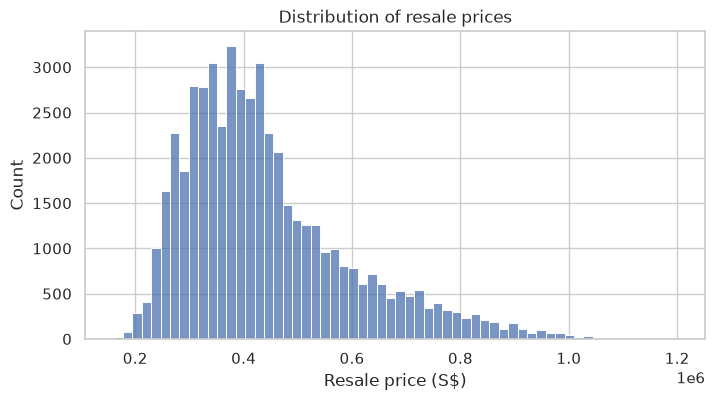

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["resale_price"], bins=60, ax=ax)
ax.set(title="Distribution of resale prices", xlabel="Resale price (S$)")
plt.show()

The distribution is **right-skewed**: most flats sell for S$300k to S$500k, with a long tail of expensive flats. Large errors on those expensive flats will dominate RMSE.

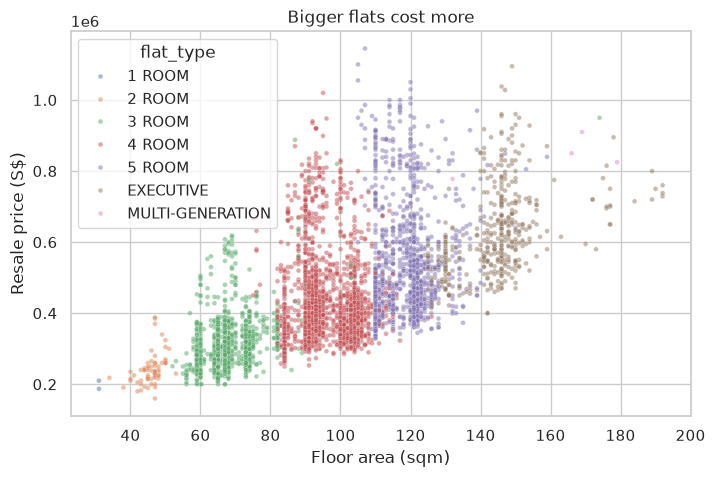

In [10]:
sample = df.sample(5000, random_state=RANDOM_STATE)
order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE", "MULTI-GENERATION"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x="floor_area_sqm", y="resale_price", hue="flat_type",
                hue_order=order, alpha=0.5, s=12, ax=ax)
ax.set(title="Bigger flats cost more", xlabel="Floor area (sqm)", ylabel="Resale price (S$)")
plt.show()

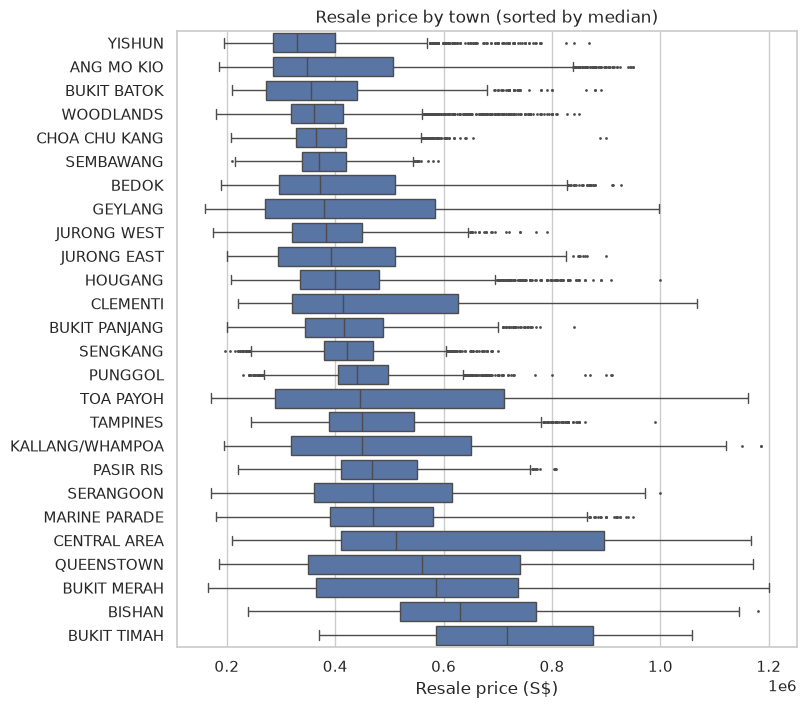

In [11]:
town_order = df.groupby("town")["resale_price"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(data=df, y="town", x="resale_price", order=town_order, fliersize=1, ax=ax)
ax.set(title="Resale price by town (sorted by median)", xlabel="Resale price (S$)", ylabel="")
plt.show()

Location matters a lot: the same size of flat costs far more in central towns than in outer towns. A model that ignores `town` will miss much of the story.

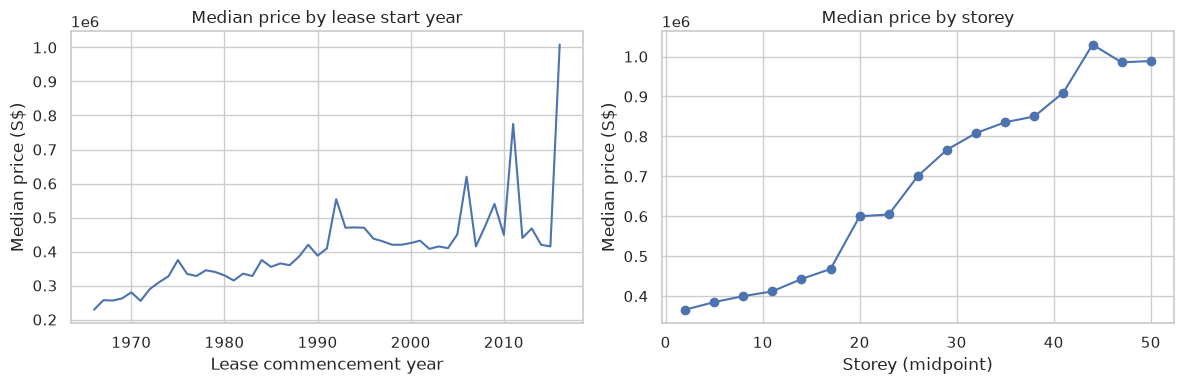

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("lease_commence_date")["resale_price"].median().plot(ax=axes[0])
axes[0].set(title="Median price by lease start year", xlabel="Lease commencement year", ylabel="Median price (S$)")
df.groupby("storey")["resale_price"].median().plot(marker="o", ax=axes[1])
axes[1].set(title="Median price by storey", xlabel="Storey (midpoint)", ylabel="Median price (S$)")
plt.tight_layout()
plt.show()

Newer leases and higher floors both go with higher prices. Notice the curves are **not straight lines**. Keep that in mind when we compare a linear model to tree-based models.

## Part 4: Train/test split and preprocessing

### 4.1 Choose features and split

We hold back **20% of the data as a test set**. We do not look at it until the very end. It stands in for "future flats the model has never seen".

In [13]:
CATEGORICAL_FEATURES = ["town", "flat_type"]
NUMERIC_FEATURES = ["floor_area_sqm", "storey", "lease_commence_date"]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X = df[FEATURES]
y = df["resale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training rows: {len(X_train):,}   Test rows: {len(X_test):,}")

Training rows: 40,345   Test rows: 10,087


### 4.2 One-hot encoding inside a Pipeline

`town` and `flat_type` are text. **One-hot encoding** turns each category into its own 0/1 column, so `town = BISHAN` becomes `town_BISHAN = 1` and every other town column is 0.

We wrap the encoder and the model in a **`Pipeline`**:
- The encoder is fitted on training data only, so no information leaks from the test set.
- The saved pipeline takes **raw** columns, so the web app can pass in `"BISHAN"` directly.

In [14]:
def build_pipeline(regressor):
    preprocess = ColumnTransformer(
        [("onehot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
        remainder="passthrough",  # numeric columns pass through unchanged
    )
    return Pipeline([("preprocess", preprocess), ("model", regressor)])

encoded = build_pipeline(LinearRegression())[0].fit(X_train).get_feature_names_out()
print(f"{len(FEATURES)} raw columns become {len(encoded)} model inputs, e.g.:")
print(encoded[:3], "...", encoded[-3:])

5 raw columns become 36 model inputs, e.g.:
['onehot__town_ANG MO KIO' 'onehot__town_BEDOK' 'onehot__town_BISHAN'] ... ['remainder__floor_area_sqm' 'remainder__storey'
 'remainder__lease_commence_date']


### 4.3 How we measure error

| Metric | Meaning | Good value |
|---|---|---|
| **MAE** (mean absolute error) | Average size of the error in S\$. Easy to explain: "off by S\$X on average" | Lower |
| **RMSE** (root mean squared error) | Like MAE but punishes big misses more | Lower |
| **R²** | Share of price variation explained (1.0 = perfect, 0 = no better than guessing the average) | Higher |

In [15]:
results = {}

def evaluate(name, pipeline):
    """Fit on the training set, score on the test set, and remember the result."""
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "fit_seconds": fit_seconds,
    }
    return pd.Series(results[name], name=name)

### 4.4 A baseline

Always start with a "dumb" baseline that predicts the average price for every flat. Any real model must beat it.

In [16]:
evaluate("Baseline (predict mean)", DummyRegressor(strategy="mean"))

MAE           119,095.86
RMSE          155,087.73
R2                 -0.00
fit_seconds         0.00
Name: Baseline (predict mean), dtype: float64

## Part 5: Model 1, Linear Regression

Linear Regression fits a weighted sum:

$$\text{price} = b_0 + b_1 \cdot \text{floor area} + b_2 \cdot \text{storey} + \dots + b_k \cdot \text{town\_BISHAN} + \dots$$

- **Strengths:** fast, tiny, easy to explain (each coefficient is "S\$ per unit").
- **Weaknesses:** assumes every effect is a straight line and adds up independently. It cannot learn that an extra square metre is worth more in Bishan than in Woodlands.

First, how well does it do with **only the three numeric columns** (no town, no flat type)?

In [17]:
numeric_only = LinearRegression().fit(X_train[NUMERIC_FEATURES], y_train)
pred = numeric_only.predict(X_test[NUMERIC_FEATURES])
print(f"Numeric features only:  R² = {r2_score(y_test, pred):.3f}   "
      f"MAE = S${mean_absolute_error(y_test, pred):,.0f}")

Numeric features only:  R² = 0.539   MAE = S$78,025


Now add `town` and `flat_type` through our pipeline:

In [18]:
lr = build_pipeline(LinearRegression())
evaluate("Linear Regression", lr)

MAE           46,725.92
RMSE          60,520.80
R2                 0.85
fit_seconds        0.19
Name: Linear Regression, dtype: float64

Adding location and flat type gives a big improvement, which shows that **feature engineering often matters more than the choice of algorithm**.

Because the model is linear, we can read its coefficients directly:

In [19]:
coefs = pd.Series(lr[-1].coef_, index=lr[0].get_feature_names_out())
print("S$ per extra unit (numeric features):")
print(coefs[[f"remainder__{c}" for c in NUMERIC_FEATURES]].round(0))
print("\nLargest town coefficients (higher = pricier location, all else equal):")
print(coefs.filter(like="town_").sort_values(ascending=False).head(5).round(0))

S$ per extra unit (numeric features):
remainder__floor_area_sqm        3,771.00
remainder__storey                4,790.00
remainder__lease_commence_date   4,808.00
dtype: float64

Largest town coefficients (higher = pricier location, all else equal):
onehot__town_BUKIT TIMAH     222,231.00
onehot__town_CENTRAL AREA    182,228.00
onehot__town_MARINE PARADE   179,099.00
onehot__town_QUEENSTOWN      134,578.00
onehot__town_BISHAN          133,188.00
dtype: float64


## Part 6: Model 2, Random Forest

A **decision tree** asks yes/no questions ("floor area > 100 sqm?", "town is BISHAN?") and predicts the average price of the flats that end up in each leaf.

A **Random Forest** trains many trees, each on a random sample of rows and columns, and **averages** their predictions. Averaging cancels out individual trees' mistakes.

- **Strengths:** captures non-linear effects and interactions automatically; little tuning needed.
- **Weaknesses:** a large file (it stores every tree), slower to predict, harder to explain.

Key settings: `n_estimators` (number of trees) and `min_samples_leaf` (smallest leaf; larger values give simpler trees).

In [20]:
rf = build_pipeline(
    RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1,
                          random_state=RANDOM_STATE)
)
evaluate("Random Forest", rf)

MAE           25,096.54
RMSE          35,623.37
R2                 0.95
fit_seconds        3.29
Name: Random Forest, dtype: float64

## Part 7: Model 3, Gradient Boosting

**Gradient Boosting** also uses many trees, but builds them **one after another**. Each new small tree tries to fix the errors the previous trees still make. `learning_rate` controls how big each correction is.

- **Strengths:** often the most accurate option on tabular data; the saved model is compact (many shallow trees).
- **Weaknesses:** trees are built one at a time, so training is slower, and more settings need tuning.

Key settings: `n_estimators` (number of rounds), `max_depth` (size of each tree), `learning_rate`.

In [21]:
gb = build_pipeline(
    GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.1,
                              random_state=RANDOM_STATE)
)
evaluate("Gradient Boosting", gb)

MAE           26,191.54
RMSE          35,813.68
R2                 0.95
fit_seconds       14.40
Name: Gradient Boosting, dtype: float64

## Part 8: A fair comparison with cross-validation

So far each model was scored once on the test set. Two problems:
1. One split can be lucky or unlucky.
2. If we pick the winner **by looking at the test set**, the test set is no longer "unseen". Our final score would be optimistic.

**5-fold cross-validation** fixes this. It splits the *training* data into 5 parts, trains on 4 and scores on the 5th, and repeats 5 times. We choose the model using these scores and keep the test set for one final check.

In [22]:
models = {"Linear Regression": lr, "Random Forest": rf, "Gradient Boosting": gb}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = {}
for name, pipeline in models.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, n_jobs=-1,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    )
    cv_rows[name] = {
        "CV RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
        "CV RMSE std": scores["test_neg_root_mean_squared_error"].std(),
        "CV MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "CV R2": scores["test_r2"].mean(),
    }

cv_table = pd.DataFrame(cv_rows).T.sort_values("CV RMSE")
cv_table

,CV RMSE,CV RMSE std,CV MAE,CV R2
Gradient Boosting,"36,120.59",169.78,"26,338.26",0.94
Random Forest,"36,662.21",490.11,"25,629.30",0.94
Linear Regression,"60,245.26",462.34,"46,370.58",0.85


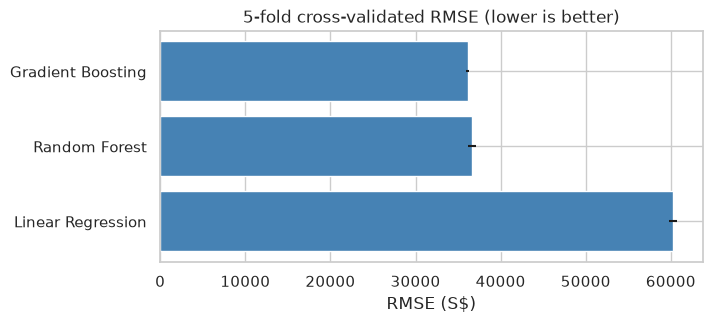

In [24]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(cv_table.index, cv_table["CV RMSE"], xerr=cv_table["CV RMSE std"], color="steelblue")
ax.invert_yaxis()
ax.set(title="5-fold cross-validated RMSE (lower is better)", xlabel="RMSE (S$)")
plt.show()

Accuracy is not the only thing that matters when deploying. Compare model size and speed too:

In [23]:
def size_mb(pipeline):
    buffer = io.BytesIO()
    joblib.dump(pipeline, buffer, compress=3)
    return buffer.tell() / 1e6

def predict_ms(pipeline, n=1000):
    start = time.perf_counter()
    pipeline.predict(X_test.iloc[:n])
    return (time.perf_counter() - start) * 1000

trade_offs = pd.DataFrame({
    name: {
        "Test MAE": results[name]["MAE"],
        "Test R2": results[name]["R2"],
        "Train time (s)": results[name]["fit_seconds"],
        "Predict 1,000 flats (ms)": predict_ms(m),
        "File size (MB)": size_mb(m),
    }
    for name, m in models.items()
}).T
trade_offs

,Test MAE,Test R2,Train time (s),"Predict 1,000 flats (ms)",File size (MB)
Linear Regression,"46,725.92",0.85,0.19,43.29,0.00
Random Forest,"25,096.54",0.95,3.29,74.56,26.05
Gradient Boosting,"26,191.54",0.95,14.40,28.43,0.74


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (name, pipeline) in zip(axes, models.items()):
    pred = pipeline.predict(X_test)
    ax.scatter(y_test, pred, s=3, alpha=0.3)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, color="red", lw=1, label="perfect prediction")
    ax.set(title=f"{name}\nR² = {r2_score(y_test, pred):.3f}", xlabel="Actual price (S$)")
axes[0].set_ylabel("Predicted price (S$)")
axes[0].legend()
plt.tight_layout()
plt.show()

**Discuss before moving on:**
- Why do both tree models beat Linear Regression by so much? (Hint: look back at the curved lines in Part 3.)
- Random Forest and Gradient Boosting are close in accuracy. Which differences in the trade-off table would matter for a web app?
- When would you still choose Linear Regression?

## Part 9: Choose, test and explain the final model

**Selection rule:** choose the model with the lowest cross-validated RMSE. Then report its test-set score once, as our honest estimate of real-world performance.

In [25]:
best_name = cv_table["CV RMSE"].idxmin()
best_model = models[best_name]
print(f"Chosen model: {best_name}")
print(f"Test MAE  = S${results[best_name]['MAE']:,.0f}")
print(f"Test RMSE = S${results[best_name]['RMSE']:,.0f}")
print(f"Test R²   = {results[best_name]['R2']:.3f}")

Chosen model: Gradient Boosting
Test MAE  = S$26,192
Test RMSE = S$35,814
Test R²   = 0.947


### Where does the model make mistakes?

In [26]:
errors = X_test.assign(actual=y_test, predicted=best_model.predict(X_test))
errors["abs_error"] = (errors["actual"] - errors["predicted"]).abs()
errors.groupby("flat_type")["abs_error"].agg(["mean", "count"]).sort_values("mean")

,mean,count
flat_type,,
1 ROOM,"10,558.86",4
2 ROOM,"15,755.86",137
3 ROOM,"19,832.82",2448
4 ROOM,"24,854.87",4183
5 ROOM,"30,797.65",2478
EXECUTIVE,"39,443.74",829
MULTI-GENERATION,"57,398.88",8


The average error grows with flat size, because bigger flats cost more and a 5% miss on S$700k is larger than on S$250k. Also check the `count` column: 1 ROOM and MULTI-GENERATION have only a handful of test flats, so we cannot say much about how well the model handles them. Always tell users where your model is weak or untested.

### Which features matter most?

**Permutation importance** shuffles one column at a time and measures how much worse the model gets. It works on the raw columns, so `town` is scored as a single feature rather than 26 one-hot columns.

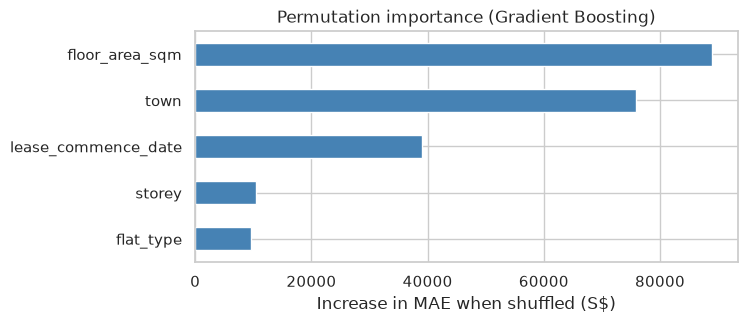

In [27]:
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
ax = importance.plot.barh(figsize=(7, 3), color="steelblue")
ax.set(title=f"Permutation importance ({best_name})", xlabel="Increase in MAE when shuffled (S$)")
plt.show()

## Part 10: From notebook to app

A notebook is great for exploring. For deployment we want a script that runs the same steps every time. **`model.py`** does exactly what this notebook did:

1. Loads the data and adds the `storey` feature (via `hdb_features.py`)
2. Trains the same three pipelines with the same settings
3. Compares them with 5-fold cross-validation and picks the lowest CV RMSE
4. Saves the winner to `models/hdb_price_model.joblib`
5. Saves `models/model_card.json` with every model's scores plus the towns, flat types and value ranges the app needs

Run it from the terminal:

```bash
python model.py
streamlit run app.py
```

Here is what the app does when you click **Predict**: it builds a one-row DataFrame with the *same column names* and passes it to the pipeline.

In [28]:
flat = pd.DataFrame(
    [["BISHAN", "4 ROOM", 95, 11, 1990]],
    columns=FEATURES,
)
print(f"Predicted price: S${best_model.predict(flat)[0]:,.0f}")

Predicted price: S$581,380


## Exercises

1. **More features:** add `flat_model` to `CATEGORICAL_FEATURES`. Does cross-validated RMSE improve? What would you have to change in `app.py`?
2. **Tuning:** try `n_estimators=50` and `min_samples_leaf=5` for Random Forest. How do accuracy and file size change?
3. **Learning rate:** train Gradient Boosting with `learning_rate=0.05` and `n_estimators=1000`. Is it worth the extra training time?
4. **Log target:** prices are right-skewed. Wrap a model in `sklearn.compose.TransformedTargetRegressor(func=np.log, inverse_func=np.exp)`. Does Linear Regression improve?
5. **Fresher data:** download the latest resale data from [data.gov.sg](https://data.gov.sg/datasets?query=hdb+resale) and retrain. How much have prices changed since 2019? (You will need the `month` column as a feature, or train only on recent months.)
6. **Communicate:** write two sentences for a non-technical user explaining how accurate the app is.